# Evaluate NER Options

## Load data

In [2]:
import plotly.express as px
import pandas as pd

import plotly.io as pio
pio.renderers.default = "notebook_connected"

In [4]:
f1_scores = pd.read_csv("eval_f1.csv")
latency = pd.read_csv("eval_latency_ms.csv")
precision = pd.read_csv("eval_precision.csv")
recall = pd.read_csv("eval_recall.csv")

## Top 10: F1 Scores

In [8]:
f1_scores.sort_values("f1", ascending=False, inplace=True)
f1_scores.head(10)

,Run,Run ID,f1
13,o4-mini-entity_openai,55e43e84ea8a422e8c8eae2600bd3443,0.601449
15,gemini-3-flash-preview-entity,f04741e4eccc4a1e8e4235b720dc8bc3,0.576642
19,ministral-3:8b-entity,20b796b4499c4df8a3c799a086fe076e,0.575439
14,o4-mini-basic_openai-slim,64b1c0c79c2d4efeb07ba78b24c861f0,0.563758
36,qwen3:8b-basic,f61f03c2420d4c048006019200a29f3f,0.557377
4,gpt-4o-mini-basic_openai-slim,8bca20388ade4fc28b7cb9d9bb234203,0.557252
18,ministral-3:14b-entity,a4c1277ff0364884829d47856f573195,0.556338
32,gpt-oss:20b-basic,1eebd4daa10a46bf8023b12f52d78b6c,0.554745
10,gpt-5-mini-basic_openai-slim,54c75fe03e994317bd63387e77203290,0.539683
26,gemma3:12b-entity,cdd0b2883952402fad99a41c43e7903d,0.539062


## Latency Overview

In [22]:
avg_latency = latency.groupby("Run", as_index=False)["value"].mean().reset_index()



avg_latency.sort_values("value", ascending=True, inplace=True)

avg_latency.head(16)

,index,Run,value
22,22,granite4:3b-entity,1345.769715
3,3,gemini-2.5-flash-lite-entity,1741.752362
21,21,granite4:3b-basic,2528.227353
2,2,gemini-2.5-flash-lite-basic,2832.523680
28,28,ministral-3:3b-entity,2913.781834
11,11,gemma3:4b-entity,3395.415854
38,38,rnj-1:latest-entity,4585.697126
15,15,gpt-4o-mini-entity_openai-slim,4703.581524
14,14,gpt-4o-mini-entity_openai,4941.240478
0,0,Qwen/Qwen3-0.6B-basic_vllm,5125.562167


In [ ]:

avg_latency = latency.groupby("Run", as_index=False)["value"].mean().reset_index()


import plotly.express as px
fig = px.box(latency, x="Run", y="value", points="all",
             title="Latency distribution for all  runs")
fig.update_layout(xaxis_tickangle=-45, yaxis_title="Latency (ms)", showlegend=False, height=600)
fig.show()

/tmp/ipykernel_20420/2144292666.py:11: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




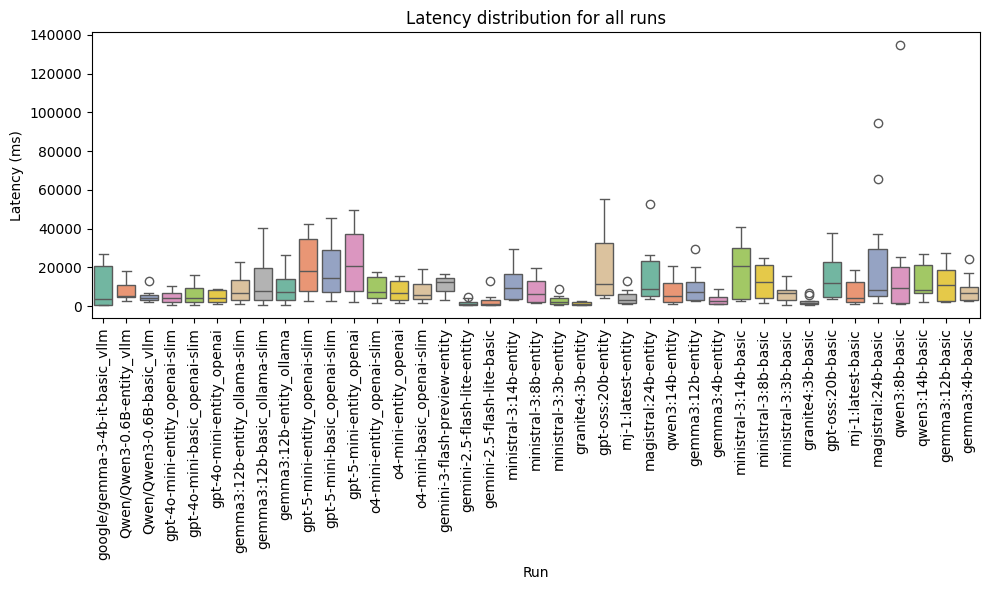

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt


avg_latency = latency.groupby("Run", as_index=False)["value"].mean().reset_index()
top_runs = avg_latency.sort_values("value", ascending=True)["Run"].tolist()
df_top = latency[latency["Run"].isin(top_runs)].copy()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_top, x="Run", y="value",  palette="Set2")
plt.title("Latency distribution for all runs")
plt.xlabel("Run")
plt.ylabel("Latency (ms)")
plt.xticks(rotation=90)  
plt.tight_layout()
plt.tight_layout()
plt.show()




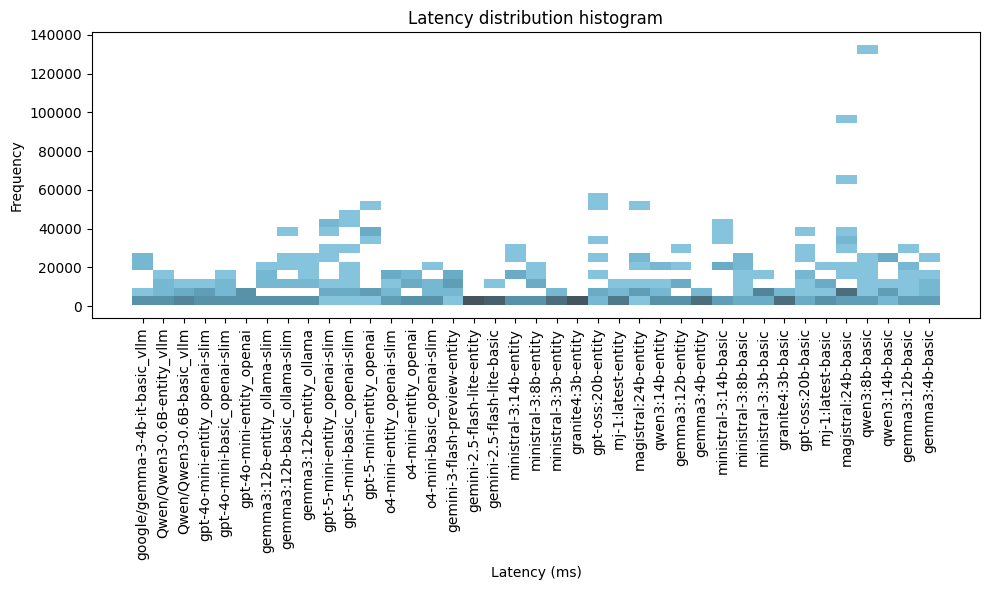

In [52]:
plt.figure(figsize=(10, 6))
sns.histplot(df_top,x="Run", y="value", bins=30, kde=True, color='skyblue')
plt.title("Latency distribution histogram")
plt.xlabel("Latency (ms)")
plt.ylabel("Frequency")
plt.xticks(rotation=90)  
plt.tight_layout()
plt.show()

## Evaluation

### Load data

In [31]:
from ranker import load_metrics, rank_models, parse_weights


df = load_metrics(f1_path="eval_f1.csv", latency_path="eval_latency_ms.csv",precision_path="eval_precision.csv", recall_path="eval_recall.csv")



### Top 10 (Higher weight on latency)

In [32]:
weights = parse_weights(weight_str="f1=1,precision=1,recall=1,latency=2")
ranked = rank_models(df, weights=weights, top_k=10)
ranked

,Run,f1,precision,recall,latency_ms,score
16,gemini-2.5-flash-lite-entity,0.530035,0.675676,0.436047,1741.752362,0.885321
13,o4-mini-entity_openai,0.601449,0.798077,0.482558,8091.389251,0.850878
4,gpt-4o-mini-basic_openai-slim,0.557252,0.811111,0.424419,6112.735510,0.848774
19,ministral-3:8b-entity,0.575439,0.725664,0.476744,8008.037019,0.818780
14,o4-mini-basic_openai-slim,0.563758,0.666667,0.488372,7706.855798,0.807883
17,gemini-2.5-flash-lite-basic,0.482540,0.531469,0.441860,2832.523680,0.807421
3,gpt-4o-mini-entity_openai-slim,0.462185,0.833333,0.319767,4703.581524,0.798708
25,qwen3:14b-entity,0.531746,0.837500,0.389535,7883.888221,0.798301
20,ministral-3:3b-entity,0.440000,0.705128,0.319767,2913.781834,0.786069
15,gemini-3-flash-preview-entity,0.576642,0.774510,0.459302,11156.258798,0.767179


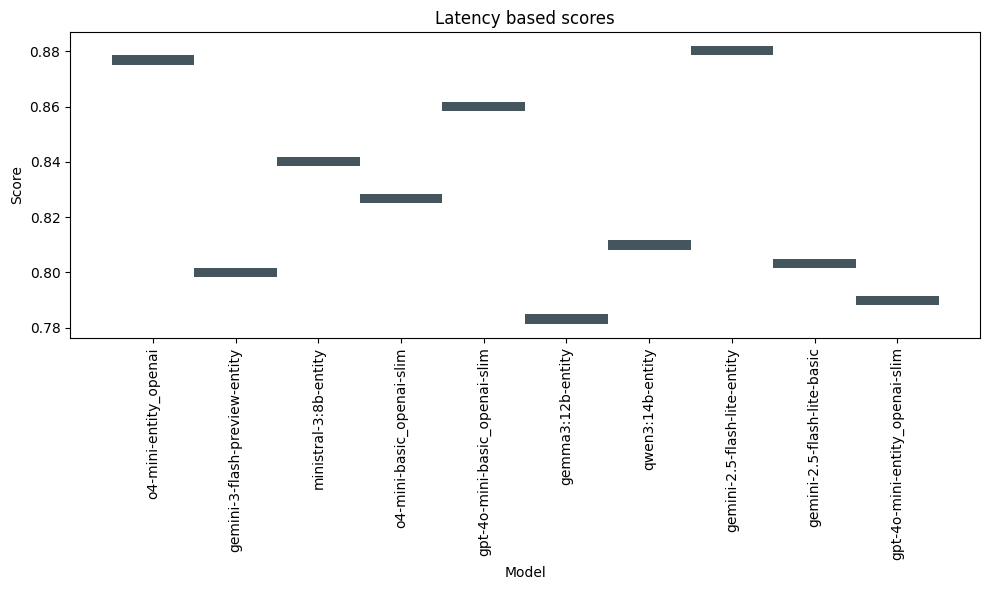

In [51]:
plt.figure(figsize=(10, 6))
sns.histplot(ranked,x="Run", y="score", bins=30, kde=True, color='skyblue')
plt.title("Latency based scores")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=90)  
plt.tight_layout()
plt.show()

### Top 10 (Higher weight on Latency and Precision)

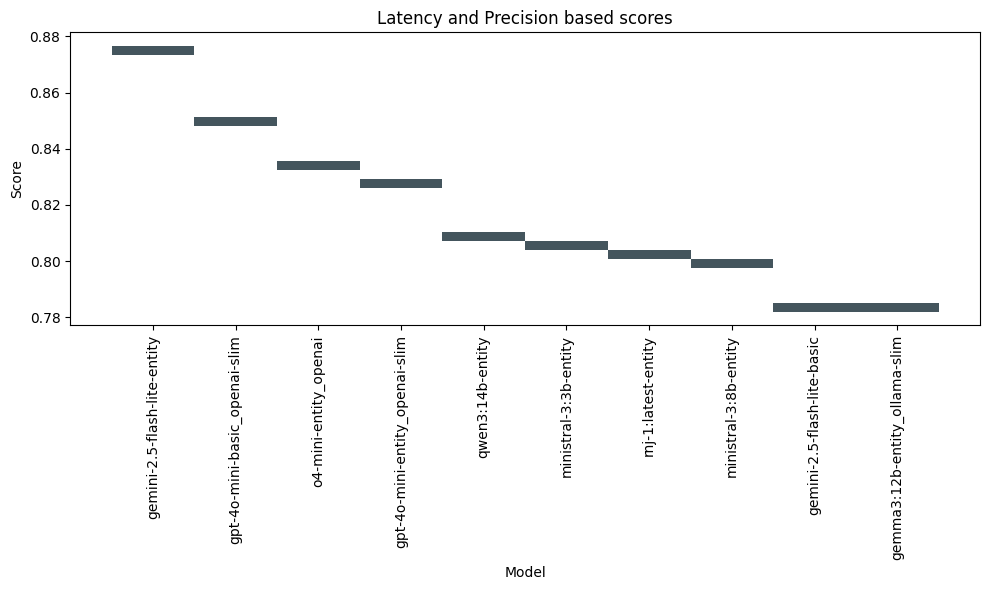

,Run,f1,precision,recall,latency_ms,score
16,gemini-2.5-flash-lite-entity,0.530035,0.675676,0.436047,1741.752362,0.876689
4,gpt-4o-mini-basic_openai-slim,0.557252,0.811111,0.424419,6112.735510,0.849860
13,o4-mini-entity_openai,0.601449,0.798077,0.482558,8091.389251,0.835493
3,gpt-4o-mini-entity_openai-slim,0.462185,0.833333,0.319767,4703.581524,0.828106
25,qwen3:14b-entity,0.531746,0.837500,0.389535,7883.888221,0.807558
20,ministral-3:3b-entity,0.440000,0.705128,0.319767,2913.781834,0.804166
23,rnj-1:latest-entity,0.422414,0.816667,0.284884,4585.697126,0.801588
19,ministral-3:8b-entity,0.575439,0.725664,0.476744,8008.037019,0.797980
17,gemini-2.5-flash-lite-basic,0.482540,0.531469,0.441860,2832.523680,0.783652
6,gemma3:12b-entity_ollama-slim,0.508197,0.861111,0.360465,8883.974671,0.781847


In [55]:
weights = parse_weights(weight_str="f1=1,precision=2,recall=1,latency=3")
ranked = rank_models(df, weights=weights, top_k=10)

plt.figure(figsize=(10, 6))
sns.histplot(ranked,x="Run", y="score", bins=30, kde=True, color='skyblue')
plt.title("Latency and Precision based scores")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=90)  
plt.tight_layout()
plt.show()
ranked

### Top 10 (Higher weights on Latency and F1)

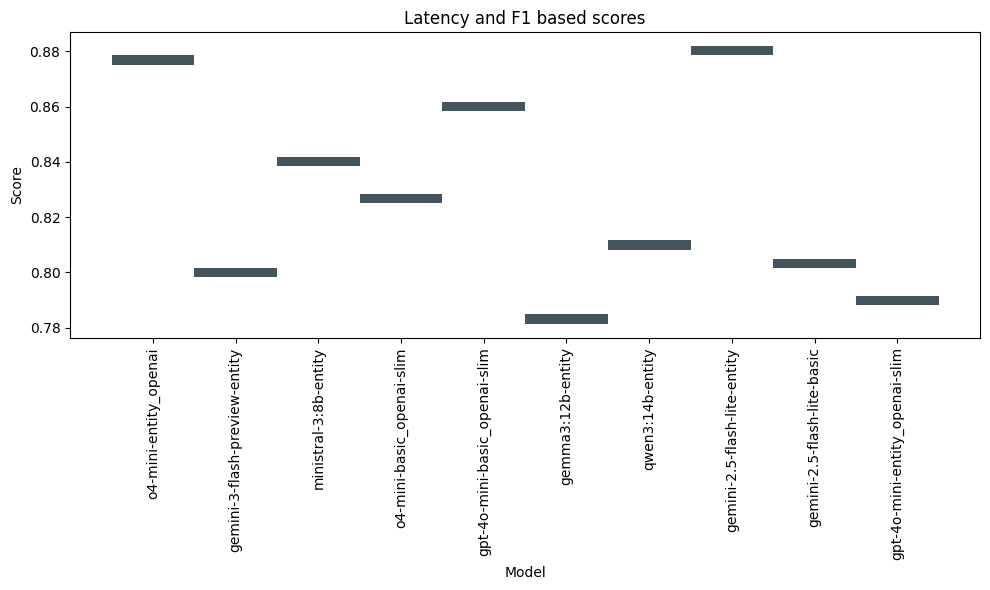

,Run,f1,precision,recall,latency_ms,score
13,o4-mini-entity_openai,0.601449,0.798077,0.482558,8091.389251,0.875732
15,gemini-3-flash-preview-entity,0.576642,0.774510,0.459302,11156.258798,0.798148
19,ministral-3:8b-entity,0.575439,0.725664,0.476744,8008.037019,0.840768
14,o4-mini-basic_openai-slim,0.563758,0.666667,0.488372,7706.855798,0.827998
4,gpt-4o-mini-basic_openai-slim,0.557252,0.811111,0.424419,6112.735510,0.860020
26,gemma3:12b-entity,0.539062,0.821429,0.401163,10048.053408,0.781387
25,qwen3:14b-entity,0.531746,0.837500,0.389535,7883.888221,0.809904
16,gemini-2.5-flash-lite-entity,0.530035,0.675676,0.436047,1741.752362,0.881880
17,gemini-2.5-flash-lite-basic,0.482540,0.531469,0.441860,2832.523680,0.801963
3,gpt-4o-mini-entity_openai-slim,0.462185,0.833333,0.319767,4703.581524,0.788273


In [56]:
weights = parse_weights(weight_str="f1=2,precision=1,recall=1,latency=2")
ranked = rank_models(df, weights=weights, top_k=10)
ranked.sort_values("f1", ascending=False, inplace=True)


plt.figure(figsize=(10, 6))
sns.histplot(ranked,x="Run", y="score", bins=30, kde=True, color='skyblue')
plt.title("Latency and F1 based scores")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=90)  
plt.tight_layout()
plt.show()
ranked



## NER Workflow Metrics Summary

### Key Metrics:

* **Latency:** Processing millions of documents can take a significant amount of time.
* **F1 Score:** Measures precision and recall balance.
* **Cost:** Affected by whether processing is done locally or in the cloud.

### Inference Cost (24/7, Nvidia 4060 TI):

* **Estimated electricity cost:** ~$20

---

### **Local Workflows**

| Model                 | F1 Score | Latency (ms) | Conclusion                                             |
| --------------------- | -------- | ------------ | ------------------------------------------------------ |
| **gemma3:12b-entity** | 0.539062 | 10,048.05    | Too slow. Consider trying a quantized version on VLLM. |
| **qwen3:14b-entity**  | 0.531746 | 7,883.89     | Good candidate to run locally.                         |

**Note:** Running **qwen3:14b-entity** on local hardware for 500,000 documents would take approximately **45 days**, with an estimated cost of **$35**.

---

### **Cloud Workflows**

| Model                            | F1 Score | Latency (ms) | Cost (for 500,000 docs)               | Conclusion                          |
| -------------------------------- | -------- | ------------ | ------------------------------------- | ----------------------------------- |
| **gemini-2.5-flash-lite-entity** | 0.530035 | 1,741.75     | **Google API:** **$150** (21 days)    | Good candidate to run on the cloud. |
| **Vertex AI**                    | 0.530035 | 1,741.75     | **$75** (1-3 days, with 50% discount) | Fast and cost-effective for cloud.  |

---

## Final Takeaways:

* **Local:** If running locally, **qwen3:14b-entity** is a good option with a reasonable cost (~$35 for 500,000 docs), but may take a long time (45 days).

* **Cloud:** For faster processing, **Vertex AI** offers the best balance between cost and speed, potentially processing in 1-3 days for $75 (with a discount).

### 500,000 Documents summary

| **Model**                                | **F1 Score** | **Estimated Duration**   | **Cost**                |
| ---------------------------------------- | ------------ | ------------------------ | ----------------------- |
| **gemma3:12b-entity (local)**            | 0.539062     | Too slow (not estimated) | ~$35  |
| **qwen3:14b-entity (local)**             | 0.531746     | 45 days                  | ~$35  |
| **gemini-2.5-flash-lite-entity (cloud)** | 0.530035     | 21 days (Google API)     | ~$150       |
| **Vertex AI (cloud)**                    | 0.530035     | 1-3 days                 | ~$75 (with vertex discount)    |
